# Regression — Price Prediction
Predict laptop price (₹) using log-transformed target; evaluate on original scale.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

df = pd.read_csv('data_features.csv', index_col='ID')

X = df.drop(columns=['Price', 'log_price'])
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (1042, 63)  Test: (261, 63)


Helper

In [2]:
def eval_on_original_scale(model, X_t, y_t):
    y_pred = np.expm1(model.predict(X_t))
    y_true = np.expm1(y_t)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return rmse, mape

kf = KFold(n_splits=5, shuffle=True, random_state=42)

XGBoost

In [3]:
def xgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 200, 1500),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        max_depth         = trial.suggest_int('max_depth', 3, 7),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
    )
    model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    return np.sqrt(-cross_val_score(model, X_train, y_train, cv=kf,
                                    scoring='neg_mean_squared_error')).mean()

xgb_study = optuna.create_study(direction='minimize')
xgb_study.optimize(xgb_objective, n_trials=60, show_progress_bar=True)
print("Best XGB params:", xgb_study.best_params)
print(f"Best CV RMSE (log): {xgb_study.best_value:.5f}")


  0%|          | 0/60 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.185902:   0%|          | 0/60 [00:03<?, ?it/s]


Best trial: 0. Best value: 0.185902:   2%|▏         | 1/60 [00:03<03:18,  3.36s/it]


Best trial: 1. Best value: 0.183616:   2%|▏         | 1/60 [00:05<03:18,  3.36s/it]


Best trial: 1. Best value: 0.183616:   3%|▎         | 2/60 [00:05<02:20,  2.42s/it]

...


Best trial: 43. Best value: 0.178929:  98%|█████████▊| 59/60 [02:35<00:04,  4.12s/it]


Best trial: 43. Best value: 0.178929:  98%|█████████▊| 59/60 [02:39<00:04,  4.12s/it]


Best trial: 43. Best value: 0.178929: 100%|██████████| 60/60 [02:39<00:00,  4.02s/it]


Best trial: 43. Best value: 0.178929: 100%|██████████| 60/60 [02:39<00:00,  2.65s/it]

Best XGB params: {'n_estimators': 1040, 'learning_rate': 0.01929818265611241, 'max_depth': 7, 'subsample': 0.6148587917614878, 'colsample_bytree': 0.5659245675839656, 'min_child_weight': 2, 'reg_alpha': 0.0020877776101407425, 'reg_lambda': 3.143257365175026}
Best CV RMSE (log): 0.17893


LightGBM

In [4]:
def lgbm_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 200, 1500),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 20, 150),
        max_depth         = trial.suggest_int('max_depth', 3, 8),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 50),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
    )
    model = LGBMRegressor(**params, random_state=42, n_jobs=-1, verbose=-1)
    return np.sqrt(-cross_val_score(model, X_train, y_train, cv=kf,
                                    scoring='neg_mean_squared_error')).mean()

lgbm_study = optuna.create_study(direction='minimize')
lgbm_study.optimize(lgbm_objective, n_trials=60, show_progress_bar=True)
print("Best LGBM params:", lgbm_study.best_params)
print(f"Best CV RMSE (log): {lgbm_study.best_value:.5f}")


  0%|          | 0/60 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.194814:   0%|          | 0/60 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.194814:   2%|▏         | 1/60 [00:00<00:19,  2.98it/s]


Best trial: 0. Best value: 0.194814:   2%|▏         | 1/60 [00:00<00:19,  2.98it/s]


Best trial: 0. Best value: 0.194814:   3%|▎         | 2/60 [00:00<00:18,  3.09it/s]

...


Best trial: 54. Best value: 0.181322:  98%|█████████▊| 59/60 [01:07<00:01,  1.34s/it]


Best trial: 54. Best value: 0.181322:  98%|█████████▊| 59/60 [01:08<00:01,  1.34s/it]


Best trial: 54. Best value: 0.181322: 100%|██████████| 60/60 [01:08<00:00,  1.39s/it]


Best trial: 54. Best value: 0.181322: 100%|██████████| 60/60 [01:08<00:00,  1.15s/it]

Best LGBM params: {'n_estimators': 1265, 'learning_rate': 0.06211047954584497, 'num_leaves': 102, 'max_depth': 4, 'subsample': 0.6596179427666423, 'colsample_bytree': 0.5396210383117309, 'min_child_samples': 5, 'reg_alpha': 0.2017195149399068, 'reg_lambda': 0.06361353101638245}
Best CV RMSE (log): 0.18132


Model Definitions

In [5]:
xgb_best  = XGBRegressor(**xgb_study.best_params,  random_state=42, n_jobs=-1)
lgbm_best = LGBMRegressor(**lgbm_study.best_params, random_state=42, n_jobs=-1, verbose=-1)

rf = RandomForestRegressor(n_estimators=400, max_features='sqrt',
                            min_samples_leaf=2, random_state=42, n_jobs=-1)
gb = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                                subsample=0.8, min_samples_leaf=3, random_state=42)

stacker = StackingRegressor(
    estimators=[('xgb', xgb_best), ('lgbm', lgbm_best), ('rf', rf), ('gb', gb)],
    final_estimator=Ridge(alpha=10),
    cv=5,
    n_jobs=-1,
)

models = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge':             Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=10))]),
    'Random Forest':     rf,
    'Gradient Boosting': gb,
    'XGBoost':           xgb_best,
    'LightGBM':          lgbm_best,
    'Stacking':          stacker,
}

Cross-Validation + Test Evaluation

In [6]:
results = {}
for name, model in models.items():
    cv_rmse = np.sqrt(-cross_val_score(model, X_train, y_train, cv=kf,
                                       scoring='neg_mean_squared_error')).mean()
    model.fit(X_train, y_train)
    test_rmse, test_mape = eval_on_original_scale(model, X_test, y_test)
    results[name] = {'CV RMSE (log-scale)': cv_rmse,
                     'Test RMSE (₹)': test_rmse,
                     'Test MAPE (%)': test_mape}

results_df = pd.DataFrame(results).T.sort_values('Test RMSE (₹)')
results_df

,CV RMSE (log-scale),Test RMSE (₹),Test MAPE (%)
Gradient Boosting,0.182183,13740.223600,13.348823
Stacking,0.179602,13949.504040,13.176782
XGBoost,0.178929,14089.305811,13.342447
LightGBM,0.181322,14655.341123,14.199903
Linear Regression,0.235363,15490.233628,18.140543
Ridge,0.234665,15512.940276,18.170023
Random Forest,0.214908,18387.781434,15.237298


Best Model — Prediction vs Actual

In [7]:
best_name  = results_df.index[0]
best_model = models[best_name]
print(f"Best model: {best_name}")
print(f"Test RMSE : ₹{results_df.loc[best_name, 'Test RMSE (₹)']:,.0f}")
print(f"Test MAPE : {results_df.loc[best_name, 'Test MAPE (%)']:.2f}%")

y_pred = np.expm1(best_model.predict(X_test))
y_true = np.expm1(y_test)

comparison = pd.DataFrame({'Actual': y_true.values, 'Predicted': y_pred}).reset_index(drop=True)
comparison['AbsError%'] = ((comparison['Predicted'] - comparison['Actual']) / comparison['Actual']).abs() * 100
comparison['AbsError%'].describe()

Best model: Gradient Boosting
Test RMSE : ₹13,740
Test MAPE : 13.35%


count    261.000000
mean      13.348823
std       14.859258
min        0.079880
25%        4.533093
50%        9.669517
75%       18.278610
max      157.350973
Name: AbsError%, dtype: float64

Feature Importance — LightGBM

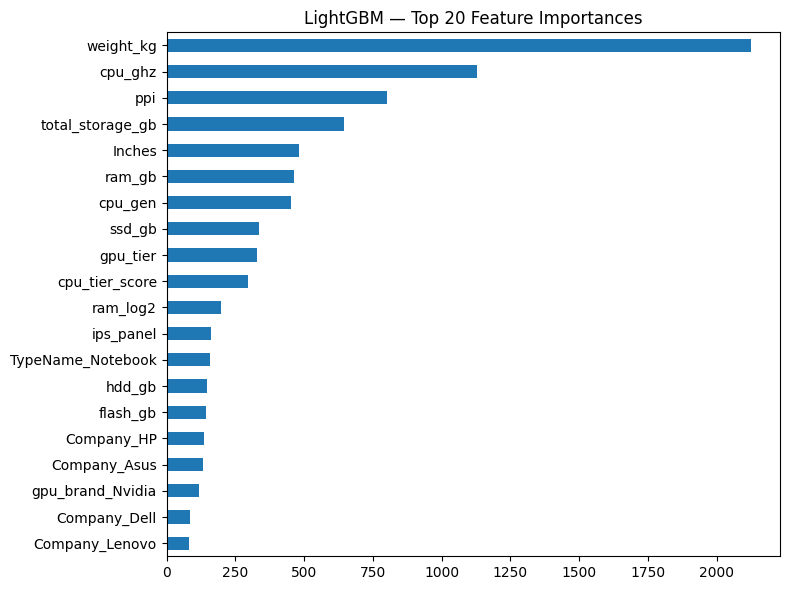

In [8]:
import matplotlib.pyplot as plt

lgbm_model = models['LightGBM']
fi = pd.Series(lgbm_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
fi.plot(kind='barh', figsize=(8, 6), title='LightGBM — Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()